[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/11_grafos_causales/notebooks/causal_intro.ipynb)

# Introducción a la Inferencia Causal

## El problema central

Imagina que observas una correlación fuerte entre dos variables $X$ e $Y$.
¿Significa que $X$ **causa** $Y$? No necesariamente.
La correlación puede existir porque una tercera variable $Z$ causa ambas:

$$
X \leftarrow Z \rightarrow Y
$$

Esto es un **fork** (bifurcación): $Z$ es una **causa común** que genera
correlación espuria entre $X$ e $Y$ sin que exista relación causal directa
entre ellas. Por ejemplo, las ventas de helado ($X$) y los ahogamientos ($Y$)
están correlacionados, pero solo porque el verano ($Z$) causa ambos.

La estadística clásica no distingue entre correlación genuina (causal) y
correlación espuria (por confounding). Para hacer esa distinción, necesitamos
el **operador $do$** de Judea Pearl:

- $P(Y \mid X = x)$ — ¿qué observamos de $Y$ cuando **vemos** que $X = x$? (correlación)
- $P(Y \mid do(X = x))$ — ¿qué pasa con $Y$ cuando **forzamos** $X = x$? (causalidad)

Estas dos cantidades pueden ser **muy diferentes** cuando hay confounders.

## Objetivo del notebook

Vamos a construir un ejemplo donde conocemos la verdad (porque generamos los datos)
y verificaremos que:

1. La correlación ingenua $P(Y \mid X)$ da una respuesta **incorrecta** (sesgo por confounding)
2. La **fórmula de ajuste** $P(Y \mid do(X)) = \sum_z P(Y \mid X, Z=z) \cdot P(Z=z)$ corrige el sesgo
3. La librería **DoWhy** automatiza este proceso

Para más detalle sobre las estructuras causales (fork, chain, collider), consulta
[01 — Estructuras Causales](../01_estructuras_causales.md). Para el operador $do$
y la fórmula de ajuste, consulta [02 — Causalidad y el Operador do](../02_do_y_causalidad.md).

### DoWhy

[DoWhy](https://www.pywhy.org/dowhy/) es una librería de Microsoft Research para inferencia causal.
Su flujo de trabajo sigue cuatro pasos:

1. **Modelar** — definir el DAG causal (nuestro conocimiento sobre qué causa qué)
2. **Identificar** — determinar qué variables ajustar (criterio backdoor)
3. **Estimar** — calcular el efecto causal $P(Y \mid do(X))$ a partir de los datos
4. **Refutar** — validar la robustez del estimado

Nosotros usaremos los pasos 1–3. Para más detalle:
- [Documentación oficial](https://www.pywhy.org/dowhy/)
- [Tutorial introductorio](https://www.pywhy.org/dowhy/main/getting_started/intro.html)
- [Repositorio en GitHub](https://github.com/py-why/dowhy)

**Nota:** La primera celda instala las dependencias. Si es la primera vez que lo ejecutas,
**reinicia el kernel** despues de que la instalacion termine (Kernel → Restart) y luego ejecuta todas las celdas desde el inicio.

In [1]:
!pip install -q dowhy pandas numpy matplotlib --upgrade

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 17.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requ

## 1. Definir el DAG causal y generar datos

### El escenario: fertilizante y cosecha

Un agricultor quiere saber si un fertilizante ($X$) mejora la cosecha ($Y$).
Pero hay un problema: la calidad del suelo ($Z$) afecta **ambas** cosas.
El agricultor tiende a echar más fertilizante en las parcelas con mejor tierra
(porque quiere maximizar ganancias), y la mejor tierra también produce más cosecha
independientemente del fertilizante.

El DAG (grafo acíclico dirigido) que describe esta situación es:

$$Z \to X, \quad Z \to Y, \quad X \to Y$$

```
      Z (suelo)
     ╱         ╲
    ↓           ↓
 X (fert.) ───→ Y (cosecha)
```

Esta es la estructura **fork**: $Z$ es la causa común de $X$ e $Y$.
La flecha $Z \to X$ dice que la calidad del suelo influye en cuánto fertilizante
se usa. La flecha $Z \to Y$ dice que el suelo influye directamente en la cosecha.
La flecha $X \to Y$ es el **efecto causal que queremos medir**.

### Ecuaciones estructurales

Un DAG nos dice *qué causa qué*, pero no *cuánto*. Para eso necesitamos
**ecuaciones estructurales** — funciones que definen cada variable en términos
de sus causas (padres en el grafo) más ruido aleatorio:

$$Z \sim \mathcal{N}(0, 1) \quad \text{(exógena: no tiene causas)}$$

$$X = \underbrace{0.7}_{\text{efecto } Z \to X} \cdot Z + \epsilon_X, \quad \epsilon_X \sim \mathcal{N}(0, 0.5)$$

$$Y = \underbrace{2.0}_{\beta: \text{ efecto causal } X \to Y} \cdot X + \underbrace{3.0}_{\text{efecto } Z \to Y} \cdot Z + \epsilon_Y, \quad \epsilon_Y \sim \mathcal{N}(0, 1)$$

El **efecto causal verdadero** de $X$ sobre $Y$ es $\beta = 2.0$.
Esto significa que si pudiéramos **intervenir** y aumentar $X$ en una unidad
*sin cambiar nada más*, $Y$ aumentaría en promedio 2.0 unidades.

Pero como $Z$ influye en $X$ ($0.7 \cdot Z$) y también en $Y$ ($3.0 \cdot Z$),
la correlación observada entre $X$ e $Y$ será **mayor** que 2.0 porque incluye
el efecto espurio de $Z$.

([ver ejemplo del agricultor en las notas](../02_do_y_causalidad.md#rct-el-operador-do-con-las-manos))

In [2]:
# ------------------------------------------------------------------
# Generar datos según las ecuaciones estructurales
# ------------------------------------------------------------------
np.random.seed(42)
n = 5000

# Parámetros causales (GROUND TRUTH)
EFECTO_VERDADERO = 2.0    # X -> Y  (lo que queremos recuperar)
efecto_z_sobre_x = 0.7   # Z -> X  (confounding: suelo bueno → más fertilizante)
efecto_z_sobre_y = 3.0   # Z -> Y  (confounding: suelo bueno → más cosecha)

# Generar datos siguiendo el DAG
Z = np.random.normal(0, 1, n)                          # Z ~ N(0,1)
X = efecto_z_sobre_x * Z + np.random.normal(0, 0.5, n) # X = 0.7*Z + ruido
Y = EFECTO_VERDADERO * X + efecto_z_sobre_y * Z + np.random.normal(0, 1, n)  # Y = 2*X + 3*Z + ruido

df = pd.DataFrame({"Z": Z, "X": X, "Y": Y})

print(f"Efecto causal verdadero de X sobre Y: {EFECTO_VERDADERO}")
print(f"Número de observaciones: {n}")
print(f"\nPrimeras filas:")
df.head(10)

Efecto causal verdadero de X sobre Y: 2.0
Número de observaciones: 5000

Primeras filas:


,Z,X,Y
0,0.496714,0.135820,1.083288
1,-0.138264,-0.323492,-1.367276
2,0.647689,-0.444440,0.456805
3,1.523030,0.901076,6.481659
4,-0.234153,0.202507,0.899733
5,-0.234137,-0.801012,-3.075477
6,1.579213,1.629690,8.997840
7,0.767435,0.781092,3.082816
8,-0.469474,-0.695749,-3.647548
9,0.542560,0.309027,3.064329


## 2. Verificar el confounding

### ¿Qué es confounding?

Un **confounder** es una variable que causa tanto el tratamiento como el resultado.
En nuestro DAG, $Z$ (calidad del suelo) es un confounder porque:

- $Z \to X$: el suelo bueno hace que el agricultor use más fertilizante
- $Z \to Y$: el suelo bueno produce más cosecha independientemente del fertilizante

Esto crea un **camino espurio** (backdoor path) entre $X$ e $Y$:
$X \leftarrow Z \rightarrow Y$. La correlación que observamos entre $X$ e $Y$
tiene dos componentes:

$$\text{Correlación}(X, Y) = \underbrace{\text{efecto causal real}}_{\beta = 2.0} + \underbrace{\text{sesgo por confounding}}_{\text{vía } Z}$$

### Diagnóstico con la matriz de correlación

Si el confounding existe, esperamos ver tres correlaciones significativas:

| Correlación | ¿Por qué? | Interpretación |
|---|---|---|
| $\text{Corr}(X, Z) > 0$ | $Z \to X$ en el DAG | El confounder influye en el tratamiento |
| $\text{Corr}(Z, Y) > 0$ | $Z \to Y$ en el DAG | El confounder influye en el resultado |
| $\text{Corr}(X, Y) > 0$ | $X \to Y$ **+** $X \leftarrow Z \rightarrow Y$ | Mezcla de efecto causal + espurio |

En un fork $X \leftarrow Z \rightarrow Y$, la regla dice que $X$ e $Y$ están
correlacionados, pero si condicionamos en $Z$ (fijamos su valor), la correlación
espuria **desaparece** y solo queda el efecto causal real
([ver fork en las notas](../01_estructuras_causales.md#1-fork-bifurcación--confounding)).

In [3]:
# Correlaciones entre las variables
print("Matriz de correlación:")
print(df.corr().round(3).to_string())
print(f"\nCorrelación X-Z: {df['X'].corr(df['Z']):.3f}  (Z influye en X → confounding)")
print(f"Correlación Z-Y: {df['Z'].corr(df['Y']):.3f}  (Z influye en Y → confounding)")
print(f"Correlación X-Y: {df['X'].corr(df['Y']):.3f}  (mezcla efecto causal + espurio)")
print(f"\n→ Z confunde la relación X-Y. La correlación X-Y no refleja solo el efecto causal.")

Matriz de correlación:
       Z      X      Y
Z  1.000  0.810  0.951
X  0.810  1.000  0.898
Y  0.951  0.898  1.000

Correlación X-Z: 0.810  (Z influye en X → confounding)
Correlación Z-Y: 0.951  (Z influye en Y → confounding)
Correlación X-Y: 0.898  (mezcla efecto causal + espurio)

→ Z confunde la relación X-Y. La correlación X-Y no refleja solo el efecto causal.


## 3. Estimación ingenua — $P(Y \mid X)$ (INCORRECTA)

### ¿Qué hace la regresión simple?

Cuando hacemos una regresión $Y \sim X$ (sin incluir $Z$), estamos estimando
la **probabilidad condicional** $P(Y \mid X = x)$, que responde a la pregunta:
*"entre las observaciones donde $X = x$, ¿cuál es el valor esperado de $Y$?"*

Pero esta **no** es la pregunta causal. La pregunta causal es:
*"si **forzamos** $X = x$ (cortando la influencia de $Z$ sobre $X$),
¿cuál es el valor esperado de $Y$?"*

### ¿Por qué la estimación ingenua está sesgada?

Pensémoslo con las fórmulas. La probabilidad condicional se puede descomponer como:

$$P(Y \mid X = x) = \sum_z P(Y \mid X=x, Z=z) \cdot \underbrace{P(Z=z \mid X=x)}_{\text{pesos SESGADOS}}$$

Los pesos son $P(Z \mid X)$ — la distribución de $Z$ **entre las observaciones con un valor específico de $X$**. Como $Z$ causa $X$, estos pesos están sesgados:
cuando $X$ es alto, es más probable que $Z$ también sea alto (buena tierra),
y la buena tierra produce más cosecha **independientemente** del fertilizante.

Compara con la **fórmula de ajuste** (la estimación causal correcta):

$$P(Y \mid do(X=x)) = \sum_z P(Y \mid X=x, Z=z) \cdot \underbrace{P(Z=z)}_{\text{pesos de la POBLACIÓN}}$$

La única diferencia es el peso: $P(Z)$ (distribución general) vs $P(Z \mid X)$ (distribución sesgada).
La fórmula de ajuste "repesa" cada estrato de $Z$ por su proporción real en la población,
eliminando el sesgo. ([ver la comparación en las notas](../02_do_y_causalidad.md#la-fórmula-de-ajuste))

### Intuición con números

Supón que $X$ es alto. En los datos observacionales, eso probablemente significa
que $Z$ (suelo) también es bueno. Entonces $Y$ (cosecha) será alta por **dos razones**:
el fertilizante ($X \to Y$) **y** el buen suelo ($Z \to Y$). La regresión simple
atribuye **todo** el aumento de $Y$ al fertilizante, sobreestimando su efecto.

In [4]:
# ------------------------------------------------------------------
# Estimación ingenua — regresión Y ~ X (sin ajustar por Z)
# ------------------------------------------------------------------

# Mínimos cuadrados: Y = a + b*X
# El coeficiente b estima dY/dX, pero INCLUYENDO el efecto espurio de Z
coefs_naive = np.polyfit(df["X"], df["Y"], 1)
estimado_naive = coefs_naive[0]

print(f"Estimación INGENUA (sin ajustar): {estimado_naive:.3f}")
print(f"Efecto verdadero:                 {EFECTO_VERDADERO}")
print(f"Sesgo:                            {estimado_naive - EFECTO_VERDADERO:+.3f}")
print(f"\n⚠️  La estimación ingenua SOBREESTIMA el efecto causal.")
print(f"    Esto ocurre porque Z causa tanto X como Y (confounding).")
print(f"    El coeficiente naive captura: efecto real (2.0) + sesgo por Z (+{estimado_naive - EFECTO_VERDADERO:.1f})")

Estimación INGENUA (sin ajustar): 4.806
Efecto verdadero:                 2.0
Sesgo:                            +2.806

⚠️  La estimación ingenua SOBREESTIMA el efecto causal.
    Esto ocurre porque Z causa tanto X como Y (confounding).
    El coeficiente naive captura: efecto real (2.0) + sesgo por Z (+2.8)


### Derivación: ¿de dónde sale el sesgo?

El estimador OLS de la regresión simple $Y \sim X$ es:

$$\hat{\beta}_{\text{naive}} = \frac{\text{Cov}(X, Y)}{\text{Var}(X)}$$

Sustituyendo la ecuación estructural $Y = \beta_1 X + \beta_2 Z + \epsilon$ (con $\epsilon$ independiente de $X$ y $Z$):

$$\hat{\beta}_{\text{naive}} = \frac{\text{Cov}(X,\; \beta_1 X + \beta_2 Z + \epsilon)}{\text{Var}(X)} = \beta_1 + \beta_2 \cdot \frac{\text{Cov}(X, Z)}{\text{Var}(X)}$$

El segundo término es el **sesgo por variable omitida**: es proporcional a $\beta_2$ (efecto del confounder sobre $Y$) y a la correlación entre $X$ y $Z$.
En nuestro ejemplo ambos son positivos ($\beta_2 = 3.0$, $\text{Cov}(X,Z) > 0$), así que el sesgo es positivo → sobreestimación.

Al incluir $Z$ en la regresión ($Y \sim X + Z$), ese término desaparece y recuperamos $\hat{\beta}_1 \approx \beta_1$.

([ver fórmula de ajuste en las notas](../02_do_y_causalidad.md#la-fórmula-de-ajuste))

## 4. Ajuste manual — la fórmula de ajuste (backdoor adjustment)

### La fórmula clave

La **fórmula de ajuste** nos permite calcular el efecto causal $P(Y \mid do(X))$
a partir de datos observacionales, siempre y cuando conozcamos el confounder $Z$:

$$P(Y \mid do(X=x)) = \sum_z P(Y \mid X=x, Z=z) \cdot P(Z=z)$$

¿De dónde sale esta fórmula? Del **operador $do$** y la **cirugía de grafos**.
Cuando hacemos $do(X = x)$, cortamos todas las flechas que llegan a $X$ en el DAG
(en nuestro caso, cortamos $Z \to X$). En el grafo mutilado, $X$ ya no depende de $Z$:

```
Grafo original:              Grafo mutilado (do(X=x)):
      Z                            Z
     ╱ ╲                             ╲
    ↓   ↓                             ↓
    X → Y                        X → Y
                                  (fijado)
```

En el grafo mutilado, $X$ y $Z$ son independientes, así que podemos promediar
sobre $Z$ usando su distribución marginal $P(Z)$ — no la distribución condicional $P(Z \mid X)$.

### ¿Cómo se implementa con regresión?

Con datos continuos y un modelo lineal, la fórmula de ajuste es **equivalente**
a una regresión múltiple:

$$Y = \beta_0 + \beta_1 X + \beta_2 Z + \epsilon$$

El coeficiente $\beta_1$ estima el efecto causal de $X$ sobre $Y$.

**¿Por qué funciona?** La regresión múltiple calcula el efecto *parcial* de cada
variable, manteniendo las demás constantes. Al incluir $Z$ en la regresión,
le estamos diciendo al modelo: "calcula cómo varía $Y$ con $X$ **a igualdad de $Z$**".
Esto es exactamente lo que hace la fórmula de ajuste: estratificar por $Z$
y promediar con los pesos de la población.

Matemáticamente, el coeficiente de la regresión simple ($Y \sim X$) captura:

$$\hat{\beta}_{\text{naive}} = \beta_1 + \beta_2 \cdot \frac{\text{Cov}(X, Z)}{\text{Var}(X)}$$

El segundo término es el **sesgo por confounding**. Es proporcional a $\beta_2$
(efecto de $Z$ sobre $Y$) y a la correlación entre $X$ y $Z$. Al incluir $Z$
en la regresión, ese término desaparece y obtenemos $\hat{\beta}_1 \approx \beta_1$.

([ver la fórmula de ajuste en las notas](../02_do_y_causalidad.md#la-fórmula-de-ajuste))

In [5]:
# ------------------------------------------------------------------
# Ajuste manual — regresión múltiple Y ~ X + Z
# ------------------------------------------------------------------

# Construimos la matriz de diseño: [1, X, Z]
# Resolvemos Y = b0 + b1*X + b2*Z por mínimos cuadrados
X_mat = np.column_stack([np.ones(n), df["X"], df["Z"]])
betas = np.linalg.lstsq(X_mat, df["Y"], rcond=None)[0]
estimado_ajustado = betas[1]

print(f"Estimación AJUSTADA (controlando Z): {estimado_ajustado:.3f}")
print(f"Efecto verdadero:                    {EFECTO_VERDADERO}")
print(f"Sesgo:                               {estimado_ajustado - EFECTO_VERDADERO:+.3f}")
print(f"\n✅ Al ajustar por el confounder Z, recuperamos el efecto causal correcto.")
print(f"\nCoeficientes de la regresión Y = b0 + b1·X + b2·Z:")
print(f"  b0 (intercepto):   {betas[0]:.3f}")
print(f"  b1 (efecto X→Y):   {betas[1]:.3f}  (verdadero: {EFECTO_VERDADERO})")
print(f"  b2 (efecto Z→Y):   {betas[2]:.3f}  (verdadero: {efecto_z_sobre_y})")
print(f"\nAmbos coeficientes se recuperan correctamente: la regresión múltiple")
print(f"implementa la fórmula de ajuste cuando el modelo es lineal.")

Estimación AJUSTADA (controlando Z): 1.989
Efecto verdadero:                    2.0
Sesgo:                               -0.011

✅ Al ajustar por el confounder Z, recuperamos el efecto causal correcto.

Coeficientes de la regresión Y = b0 + b1·X + b2·Z:
  b0 (intercepto):   0.011
  b1 (efecto X→Y):   1.989  (verdadero: 2.0)
  b2 (efecto Z→Y):   3.005  (verdadero: 3.0)

Ambos coeficientes se recuperan correctamente: la regresión múltiple
implementa la fórmula de ajuste cuando el modelo es lineal.


## 5. DoWhy — inferencia causal automatizada

### ¿Qué hace DoWhy internamente?

En nuestro ejemplo simple (un confounder, modelo lineal), el ajuste manual
fue directo: incluir $Z$ en la regresión. Pero en la práctica:

- El DAG puede tener **muchas variables** y no es obvio cuáles ajustar
- Ajustar por la variable equivocada puede **empeorar** el sesgo (si es un collider,
  ajustar por él **crea** correlación espuria — lo opuesto a lo que queremos)
- Puede haber **múltiples caminos** entre $X$ e $Y$

DoWhy automatiza este razonamiento. Su pipeline tiene 4 pasos;
los dos primeros son **puramente gráficos** (operan sobre el DAG, no tocan los datos),
los últimos dos son **estadísticos**.

### El algoritmo paso a paso

**1. Enumerar caminos** entre $X$ e $Y$ (ignorando la dirección de las flechas):

En nuestro DAG ($Z \to X$, $Z \to Y$, $X \to Y$), hay dos caminos:
- Camino 1: $X \to Y$ (siguiendo las flechas — **causal**)
- Camino 2: $X \leftarrow Z \to Y$ (entra a $X$ por detrás — **backdoor/espurio**)

**2. Clasificar cada camino:**
- **Caminos causales** (frontdoor): van de $X$ a $Y$ siguiendo flechas.
  Son el efecto que queremos — **no los bloqueamos**.
- **Caminos backdoor** (espurios): tienen una flecha *entrando* a $X$.
  Crean correlación espuria — **sí los bloqueamos**.

**3. Encontrar un conjunto de ajuste $S$** que bloquee todos los caminos backdoor:
- Condicionar en un **no-collider** (fork/chain) **bloquea** el camino (bueno)
- Condicionar en un **collider** **abre** el camino (malo — crea sesgo nuevo)
- Regla: ajustar por confounders (forks) **sí**, por colliders **nunca**

En nuestro caso:
```
Camino backdoor: X ← Z → Y
  Z es no-collider → condicionar en Z BLOQUEA el camino ✓
  Resultado: S = {Z}
```

**4. Construir la fórmula de ajuste** con el conjunto $S$:

$$P(Y \mid do(X=x)) = \sum_s P(Y \mid X=x, S=s) \cdot P(S=s)$$

### Resumen visual del pipeline

```
┌─────────────┐     ┌──────────────────┐     ┌────────────┐     ┌──────────┐
│  1. MODELAR │────▶│  2. IDENTIFICAR  │────▶│ 3. ESTIMAR │────▶│4. REFUTAR│
│  (DAG)      │     │  (criterio       │     │ (regresión │     │(placebo, │
│             │     │   backdoor)      │     │  ajustada) │     │ robustez)│
│ Solo grafo  │     │  Solo grafo      │     │ Datos +    │     │ Datos    │
│ no datos    │     │  no datos        │     │ fórmula    │     │          │
└─────────────┘     └──────────────────┘     └────────────┘     └──────────┘
```

**Nota importante:** Los pasos 1 y 2 no usan datos en absoluto.
La identificación causal es un problema **gráfico**, no estadístico.
Los datos solo entran en el paso 3 (estimación).
Esto refuerza la idea central: **la causalidad viene del modelo, no de los datos.**

La siguiente celda implementa los pasos 1–4 con código para nuestro DAG,
y después usaremos DoWhy para hacer lo mismo automáticamente.

([algoritmo detallado en las notas](../02_do_y_causalidad.md#el-algoritmo-paso-a-paso))

In [6]:
# ------------------------------------------------------------------
# Visualizar el algoritmo: ¿qué hace DoWhy internamente?
# ------------------------------------------------------------------

import networkx as nx

# Nuestro DAG
dag = nx.DiGraph([('Z', 'X'), ('Z', 'Y'), ('X', 'Y')])

# Paso 1: Enumerar TODOS los caminos entre X e Y (ignorando dirección)
undirected = dag.to_undirected()
all_paths = list(nx.all_simple_paths(undirected, 'X', 'Y'))

print('=== PASO 1: Enumerar caminos entre X e Y ===')
for i, path in enumerate(all_paths):
    print(f'  Camino {i+1}: {" → ".join(path)}')

# Paso 2: Clasificar caminos
print(f'\n=== PASO 2: Clasificar caminos ===')
for path in all_paths:
    # Un camino backdoor tiene una flecha ENTRANDO a X (el primer nodo)
    # Verificar: ¿el segundo nodo en el camino es PADRE de X en el DAG?
    if len(path) >= 2 and dag.has_edge(path[1], path[0]):
        # El segundo nodo (path[1]) tiene flecha hacia X → es backdoor
        print(f'  {" → ".join(path)}  →  BACKDOOR (espurio) ← flecha entra a X')
    else:
        print(f'  {" → ".join(path)}  →  CAUSAL (no tocar)')

# Paso 3: Encontrar variables de ajuste (backdoor)
# En nuestro caso simple: los padres de X que no son descendientes de X
parents_of_X = set(dag.predecessors('X'))
descendants_of_X = set(nx.descendants(dag, 'X'))
backdoor_set = parents_of_X - descendants_of_X

print(f'\n=== PASO 3: Conjunto de ajuste (backdoor) ===')
print(f'  Padres de X:          {parents_of_X}')
print(f'  Descendientes de X:   {descendants_of_X}')
print(f'  Conjunto de ajuste S: {backdoor_set}')
print(f'  → Ajustar por: {backdoor_set}')

# Paso 4: La fórmula resultante
s_str = ', '.join(sorted(backdoor_set))
print(f'\n=== PASO 4: Fórmula de ajuste ===')
print(f'  P(Y | do(X=x)) = Σ_s P(Y | X=x, {s_str}=s) · P({s_str}=s)')
print(f'  En regresión: Y ~ X + {s_str}')
print(f'\n→ Esto es exactamente lo que hicimos a mano en la sección 4.')
print(f'  DoWhy automatiza este razonamiento gráfico.')


=== PASO 1: Enumerar caminos entre X e Y ===
  Camino 1: X → Z → Y
  Camino 2: X → Y

=== PASO 2: Clasificar caminos ===
  X → Z → Y  →  BACKDOOR (espurio) ← flecha entra a X
  X → Y  →  CAUSAL (no tocar)

=== PASO 3: Conjunto de ajuste (backdoor) ===
  Padres de X:          {'Z'}
  Descendientes de X:   {'Y'}
  Conjunto de ajuste S: {'Z'}
  → Ajustar por: {'Z'}

=== PASO 4: Fórmula de ajuste ===
  P(Y | do(X=x)) = Σ_s P(Y | X=x, Z=s) · P(Z=s)
  En regresión: Y ~ X + Z

→ Esto es exactamente lo que hicimos a mano en la sección 4.
  DoWhy automatiza este razonamiento gráfico.


### Ahora con DoWhy

Acabamos de implementar el criterio backdoor a mano. DoWhy hace exactamente lo mismo
pero de forma automatizada: recibe el DAG, encuentra los caminos backdoor,
determina el conjunto de ajuste, y estima el efecto causal.

Veamos que produce el mismo resultado.

In [7]:
# ------------------------------------------------------------------
# Paso 1: Definir el modelo causal con DoWhy
# ------------------------------------------------------------------
import networkx as nx
from dowhy import CausalModel

# Construimos el DAG como un networkx DiGraph
# Cada arista (A, B) indica que A causa directamente a B
grafo = nx.DiGraph([("Z", "X"), ("Z", "Y"), ("X", "Y")])

modelo = CausalModel(
    data=df,
    treatment="X",       # Variable cuyo efecto queremos medir
    outcome="Y",         # Variable resultado
    graph=grafo,         # Nuestro conocimiento causal
)

print("Modelo causal creado exitosamente.")
print(f"  Tratamiento: X (fertilizante)")
print(f"  Resultado:   Y (cosecha)")
print(f"  Grafo:       Z → X, Z → Y, X → Y")

Modelo causal creado exitosamente.
  Tratamiento: X (fertilizante)
  Resultado:   Y (cosecha)
  Grafo:       Z → X, Z → Y, X → Y


In [8]:
# ------------------------------------------------------------------
# Pasos 2 y 3: Identificar + Estimar
# ------------------------------------------------------------------

# Paso 2: Identificar — DoWhy analiza el grafo automáticamente
# Encuentra que Z es un confounder y que hay que ajustar por Z (backdoor)
identificado = modelo.identify_effect(proceed_when_unidentifiable=True)
print("=== IDENTIFICACIÓN (automática) ===")
print(f"Variables backdoor encontradas: {identificado.get_backdoor_variables()}")
print(f"→ DoWhy determinó que hay que ajustar por Z (igual que nosotros a mano)\n")

# Paso 3: Estimar — calcula P(Y | do(X)) usando regresión lineal con ajuste
estimacion = modelo.estimate_effect(
    identificado,
    method_name="backdoor.linear_regression",
)

estimado_dowhy = estimacion.value
print("=== ESTIMACIÓN ===")
print(f"Estimación DoWhy:  {estimado_dowhy:.3f}")
print(f"Efecto verdadero:  {EFECTO_VERDADERO}")
print(f"Sesgo:             {estimado_dowhy - EFECTO_VERDADERO:+.3f}")
print(f"\n✅ DoWhy recupera el efecto causal correcto.")
print(f"   Internamente hizo lo mismo que nosotros: regresión Y ~ X + Z.")

=== IDENTIFICACIÓN (automática) ===
Variables backdoor encontradas: ['Z']
→ DoWhy determinó que hay que ajustar por Z (igual que nosotros a mano)

=== ESTIMACIÓN ===
Estimación DoWhy:  1.989
Efecto verdadero:  2.0
Sesgo:             -0.011

✅ DoWhy recupera el efecto causal correcto.
   Internamente hizo lo mismo que nosotros: regresión Y ~ X + Z.


## 6. Comparación final

Pongamos los cuatro estimados lado a lado para ver la diferencia entre
correlación y causalidad:

| Método | Qué estima | Estimado | Sesgo | ¿Correcto? |
|--------|-----------|----------|-------|------------|
| Naive (regresión $Y \sim X$) | $P(Y \mid X)$ — correlación | ~4.8 | +2.8 | No |
| Ajuste manual ($Y \sim X + Z$) | $P(Y \mid do(X))$ — causal | ~2.0 | ~0 | Si |
| DoWhy (backdoor + regresión) | $P(Y \mid do(X))$ — causal | ~2.0 | ~0 | Si |
| Verdadero (ecuación estructural) | $\beta_{X \to Y}$ | 2.0 | 0 | — |

### ¿Qué aprendemos?

1. **Sin ajustar por $Z$**, el efecto estimado es **más del doble** del real (~4.8 vs 2.0).
   El agricultor concluiría que el fertilizante es mucho más efectivo de lo que realmente es.

2. **Ajustando por $Z$** (ya sea manualmente o con DoWhy), recuperamos el efecto
   causal verdadero. La clave es ponderar cada estrato de $Z$ por $P(Z)$ en lugar de $P(Z \mid X)$.

3. **La fórmula de ajuste produce el mismo resultado que un RCT** (ensayo aleatorizado).
   Si el agricultor hubiera lanzado una moneda para decidir qué parcelas fertilizar
   (cortando la flecha $Z \to X$), habría obtenido $\hat{\beta} \approx 2.0$ directamente.
   La inferencia causal nos da respuestas de tipo experimental **sin necesidad de experimentar**.

4. **El DAG es crucial**: sin saber que $Z$ es un confounder, no sabríamos qué ajustar.
   El grafo causal codifica nuestro conocimiento del dominio — las flechas son hipótesis
   sobre cómo funciona el mundo, no datos.

([ver Simpson resuelto en las notas](../02_do_y_causalidad.md#simpson-resuelto))

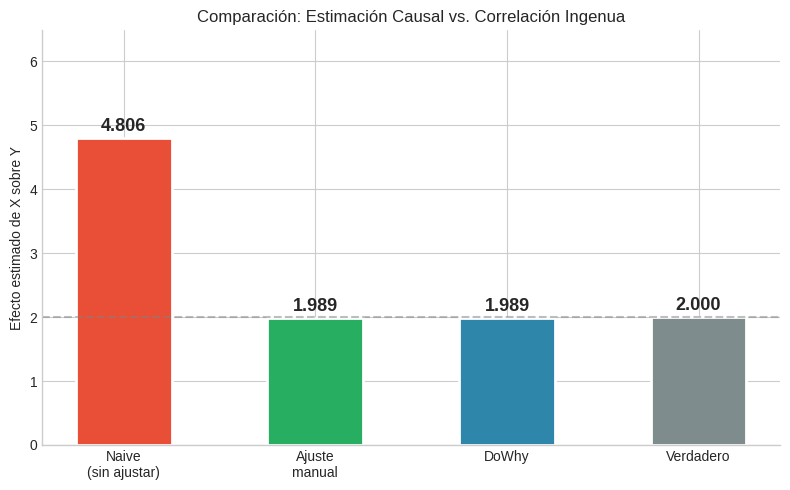


Resumen:
  Naive:    4.806  (sesgo: +2.806)
  Manual:   1.989  (sesgo: -0.011)
  DoWhy:    1.989  (sesgo: -0.011)
  Verdad:   2.0


In [9]:
# ------------------------------------------------------------------
# Comparación visual — naive vs manual vs DoWhy vs verdad
# ------------------------------------------------------------------

labels = ["Naive\n(sin ajustar)", "Ajuste\nmanual", "DoWhy", "Verdadero"]
values = [estimado_naive, estimado_ajustado, estimado_dowhy, EFECTO_VERDADERO]
colors = ["#E94F37", "#27AE60", "#2E86AB", "#7F8C8D"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor="white", linewidth=2)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=13,
    )

ax.axhline(y=EFECTO_VERDADERO, color="gray", linestyle="--", alpha=0.5, linewidth=1.5)
ax.set_ylabel("Efecto estimado de X sobre Y")
ax.set_title("Comparación: Estimación Causal vs. Correlación Ingenua")
ax.set_ylim(0, max(values) * 1.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nResumen:")
print(f"  Naive:    {estimado_naive:.3f}  (sesgo: {estimado_naive - EFECTO_VERDADERO:+.3f})")
print(f"  Manual:   {estimado_ajustado:.3f}  (sesgo: {estimado_ajustado - EFECTO_VERDADERO:+.3f})")
print(f"  DoWhy:    {estimado_dowhy:.3f}  (sesgo: {estimado_dowhy - EFECTO_VERDADERO:+.3f})")
print(f"  Verdad:   {EFECTO_VERDADERO}")

## 7. Los datos no prueban causalidad

> **Advertencia fundamental:** No se puede inferir causalidad a partir de datos.
> Sin importar cuántos datos tengas, sin importar qué tan fuerte sea la correlación.

Todo lo que hicimos en este notebook — la fórmula de ajuste, DoWhy, la regresión
múltiple — **depende del DAG**. El DAG es nuestro **modelo** del mundo: una hipótesis
sobre qué causa qué. No sale de los datos. Sale de nuestro conocimiento del dominio.

Los datos solo pueden hacer dos cosas respecto al modelo causal:

| Resultado | Significado |
|---|---|
| Las implicaciones del DAG **fallan** en los datos | El modelo es **incorrecto** (refutado) |
| Las implicaciones del DAG **se cumplen** en los datos | El modelo es **consistente** (evidencia a favor, **no prueba**) |

¿Por qué no es prueba? Porque **muchos DAGs diferentes** pueden ser consistentes con los
mismos datos. Por ejemplo, los datos no distinguen entre $X \to Y$ y $X \leftarrow Z \to Y$
si no observamos $Z$.

### ¿Qué implicaciones podemos verificar?

Cada DAG implica ciertas **independencias condicionales** entre variables
(derivadas de d-separación). Estas son **condiciones necesarias** para que el DAG
sea correcto:

- **Fork** $X \leftarrow Z \to Y$: implica $X \perp Y \mid Z$
- **Chain** $X \to M \to Y$: implica $X \perp Y \mid M$
- **Collider** $X \to C \leftarrow Y$: implica $X \perp Y$ (sin condicionar)

Si alguna de estas falla en los datos, el DAG está mal.
Si todas se cumplen, es evidencia a favor — pero otros DAGs podrían dar las mismas implicaciones.

Veamos dos diagnósticos visuales concretos.

([ver sección completa en las notas](../02_do_y_causalidad.md#los-datos-no-prueban-causalidad))

### Diagnóstico 1: Independencia condicional

Nuestro DAG dice que $Z$ es un confounder (fork). Esto implica que
si pudiéramos **eliminar** la influencia de $Z$, la correlación entre $X$ e $Y$
debería **reducirse** al efecto causal puro.

Para verificarlo visualmente, estratificamos los datos por terciles de $Z$
y comparamos la correlación $X$-$Y$ dentro de cada estrato vs la correlación total.

Para un **fork puro** (sin $X \to Y$), la correlación desaparece completamente.
En nuestro caso (fork + efecto causal), la correlación se **reduce** al efecto real.

Si la correlación NO se redujera al estratificar por $Z$, tendríamos evidencia
de que nuestro DAG es incorrecto (quizás $Z$ no es el confounder, o hay otro).

=== Correlación X-Y por estrato de Z ===
  Total (sin condicionar):  0.898
  Z bajo  (< -0.44):        0.812
  Z medio (-0.44 a 0.45):  0.741
  Z alto  (> 0.45):        0.797
  Promedio condicional:     0.783

→ La correlación se REDUCE al condicionar en Z.
  No desaparece del todo porque X → Y es real (efecto causal = 2.0).
  Esto es CONSISTENTE con nuestro DAG (fork + efecto causal).


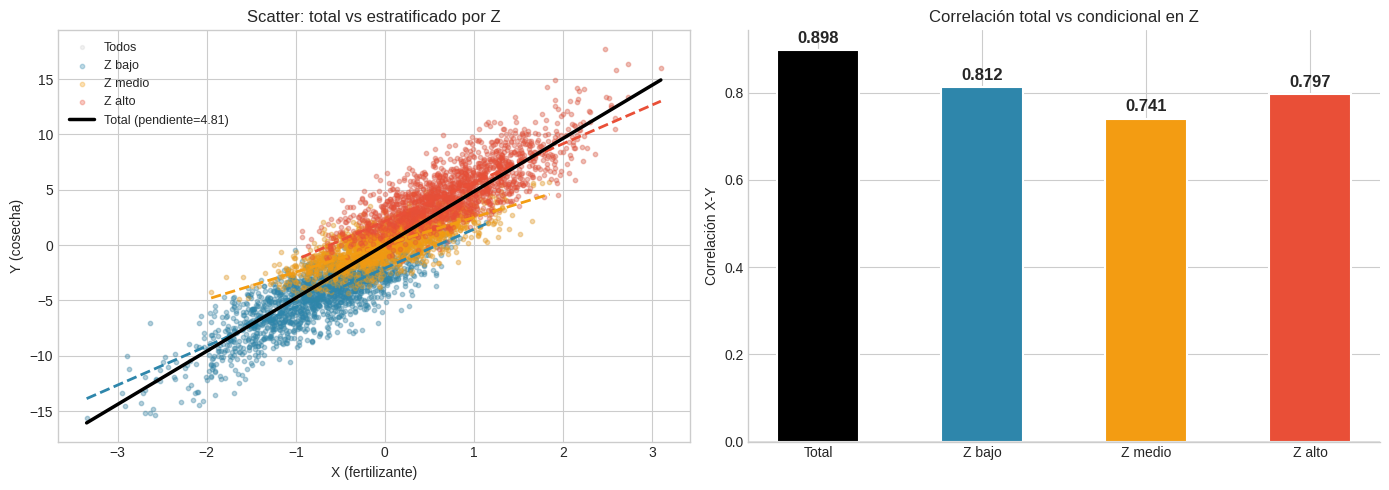

In [10]:
# ------------------------------------------------------------------
# Diagnóstico 1: Independencia condicional — ¿la correlación se reduce?
# ------------------------------------------------------------------

# Estratificar por terciles de Z
z_low = df['Z'].quantile(0.33)
z_high = df['Z'].quantile(0.67)

mask_low = df['Z'] < z_low
mask_mid = (df['Z'] >= z_low) & (df['Z'] < z_high)
mask_high = df['Z'] >= z_high

# Correlación total vs condicional
corr_total = df['X'].corr(df['Y'])
corr_low = df.loc[mask_low, 'X'].corr(df.loc[mask_low, 'Y'])
corr_mid = df.loc[mask_mid, 'X'].corr(df.loc[mask_mid, 'Y'])
corr_high = df.loc[mask_high, 'X'].corr(df.loc[mask_high, 'Y'])

print('=== Correlación X-Y por estrato de Z ===')
print(f'  Total (sin condicionar):  {corr_total:.3f}')
print(f'  Z bajo  (< {z_low:.2f}):        {corr_low:.3f}')
print(f'  Z medio ({z_low:.2f} a {z_high:.2f}):  {corr_mid:.3f}')
print(f'  Z alto  (> {z_high:.2f}):        {corr_high:.3f}')
print(f'  Promedio condicional:     {(corr_low + corr_mid + corr_high)/3:.3f}')
print(f'\n→ La correlación se REDUCE al condicionar en Z.')
print(f'  No desaparece del todo porque X → Y es real (efecto causal = {EFECTO_VERDADERO}).')
print(f'  Esto es CONSISTENTE con nuestro DAG (fork + efecto causal).')

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Scatter total vs estratificado
ax1.scatter(df['X'], df['Y'], alpha=0.1, s=8, color='gray', label='Todos')
for mask, label, color in [
    (mask_low, 'Z bajo', '#2E86AB'),
    (mask_mid, 'Z medio', '#F39C12'),
    (mask_high, 'Z alto', '#E94F37'),
]:
    subset = df[mask]
    ax1.scatter(subset['X'], subset['Y'], alpha=0.3, s=10, color=color, label=label)
    m, b = np.polyfit(subset['X'], subset['Y'], 1)
    x_line = np.linspace(subset['X'].min(), subset['X'].max(), 50)
    ax1.plot(x_line, m * x_line + b, color=color, lw=2, ls='--')

# Línea de regresión total
m_tot, b_tot = np.polyfit(df['X'], df['Y'], 1)
x_tot = np.linspace(df['X'].min(), df['X'].max(), 50)
ax1.plot(x_tot, m_tot * x_tot + b_tot, color='black', lw=2.5, label=f'Total (pendiente={m_tot:.2f})')
ax1.set_xlabel('X (fertilizante)')
ax1.set_ylabel('Y (cosecha)')
ax1.set_title('Scatter: total vs estratificado por Z')
ax1.legend(fontsize=9)

# Panel 2: Barras de correlación
labels = ['Total', 'Z bajo', 'Z medio', 'Z alto']
vals = [corr_total, corr_low, corr_mid, corr_high]
colors_bar = ['black', '#2E86AB', '#F39C12', '#E94F37']
bars = ax2.bar(labels, vals, color=colors_bar, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax2.set_ylabel('Correlación X-Y')
ax2.set_title('Correlación total vs condicional en Z')
ax2.axhline(0, color='gray', lw=1)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Diagnóstico 2: Asimetría de residuos (dirección causal)

Este diagnóstico proviene de *Elements of Causal Inference* (Peters, Janzing, Schölkopf)
y sirve para verificar la **dirección** de una relación causal.

La idea se basa en los **modelos de ruido aditivo**: si $X$ causa $Y$, entonces
$Y = f(X) + N$ donde el ruido $N$ es **independiente** de $X$. Esto produce una
asimetría detectable:

| Dirección | Regresión | Residuos |
|---|---|---|
| **Causal** ($X \to Y$) | $Y = f(X) + \text{residuos}$ | Independientes de $X$ (banda plana) |
| **Anti-causal** ($Y \to X$) | $X = g(Y) + \text{residuos}$ | Dependientes de $Y$ (estructura visible) |

**¿Por qué existe esta asimetría?** La distribución de la causa $P(X)$ y el
mecanismo causal $f$ son **independientes** entre sí — son procesos modulares
de la naturaleza que no se "conocen". En la dirección causal, los residuos
recuperan el ruido $N$ (que es independiente de $X$ por construcción), así que
son planos. En la dirección anti-causal, la función inversa $g$ no puede separar
limpiamente $X$ del ruido $N$, porque la distribución de $X$ interactúa con la
no-linealidad de $f$. El resultado: los residuos muestran **heteroscedasticidad**
(la varianza cambia con $Y$).

([ver explicación completa con la matemática en las notas](../02_do_y_causalidad.md#diagnóstico-de-residuos-cuál-es-la-dirección-causal))

Vamos a generar datos con una relación no lineal ($Y = \tanh(X) + N$) para
que la asimetría sea más visible.

**Importante:** Este diagnóstico es una condición **necesaria**, no suficiente.
Si los residuos muestran estructura en la dirección propuesta, hay evidencia en contra.
Si son planos, es **consistente** — pero no prueba que la dirección sea correcta.

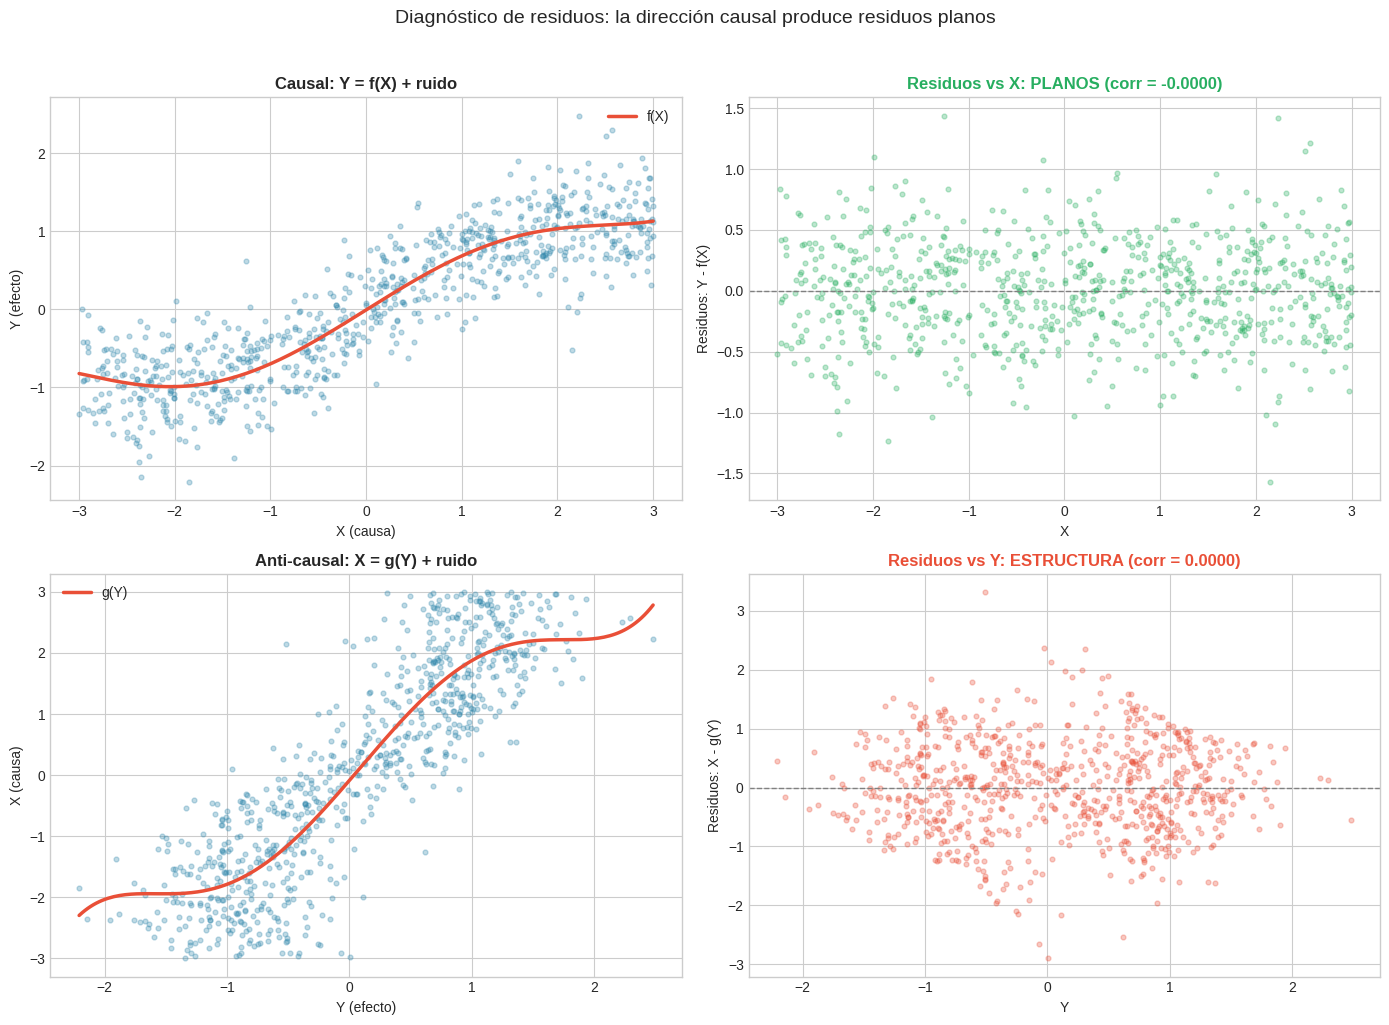


Resumen:
  Dirección causal (X→Y):      |Corr(residuos, X)| = 0.0000  (plano)
  Dirección anti-causal (Y→X):  |Corr(residuos, Y)| = 0.0000  (estructura)

→ La asimetría apoya la dirección X → Y.
  Esto es evidencia a FAVOR de nuestro modelo, no prueba.


In [11]:
# ------------------------------------------------------------------
# Diagnóstico 2: Asimetría de residuos — dirección causal
# ------------------------------------------------------------------

np.random.seed(99)
n_diag = 800

# Generar datos: X causa Y con relación no lineal
x_diag = np.random.uniform(-3, 3, n_diag)
noise_diag = np.random.normal(0, 0.4, n_diag)
y_diag = np.tanh(x_diag) + noise_diag  # Y = tanh(X) + N,  N independiente de X

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Fila 1: Dirección CAUSAL (X → Y) ---
# Ajustar Y ~ f(X) con polinomio de grado 5
coefs_causal = np.polyfit(x_diag, y_diag, 5)
x_fine = np.linspace(-3, 3, 200)

# Scatter + fit
axes[0, 0].scatter(x_diag, y_diag, alpha=0.3, s=12, color='#2E86AB')
axes[0, 0].plot(x_fine, np.polyval(coefs_causal, x_fine), color='#E94F37', lw=2.5, label='f(X)')
axes[0, 0].set_xlabel('X (causa)')
axes[0, 0].set_ylabel('Y (efecto)')
axes[0, 0].set_title('Causal: Y = f(X) + ruido', fontweight='bold')
axes[0, 0].legend()

# Residuos de Y ~ f(X) vs X → PLANOS
res_causal = y_diag - np.polyval(coefs_causal, x_diag)
axes[0, 1].scatter(x_diag, res_causal, alpha=0.3, s=12, color='#27AE60')
axes[0, 1].axhline(0, color='gray', lw=1, ls='--')
axes[0, 1].set_xlabel('X')
axes[0, 1].set_ylabel('Residuos: Y - f(X)')
corr_res_causal = np.corrcoef(x_diag, res_causal)[0, 1]
axes[0, 1].set_title(f'Residuos vs X: PLANOS (corr = {corr_res_causal:.4f})',
                     fontweight='bold', color='#27AE60')

# --- Fila 2: Dirección ANTI-CAUSAL (Y → X) ---
# Ajustar X ~ g(Y) con polinomio de grado 5
coefs_anti = np.polyfit(y_diag, x_diag, 5)
y_fine = np.linspace(y_diag.min(), y_diag.max(), 200)

# Scatter + fit
axes[1, 0].scatter(y_diag, x_diag, alpha=0.3, s=12, color='#2E86AB')
axes[1, 0].plot(y_fine, np.polyval(coefs_anti, y_fine), color='#E94F37', lw=2.5, label='g(Y)')
axes[1, 0].set_xlabel('Y (efecto)')
axes[1, 0].set_ylabel('X (causa)')
axes[1, 0].set_title('Anti-causal: X = g(Y) + ruido', fontweight='bold')
axes[1, 0].legend()

# Residuos de X ~ g(Y) vs Y → ESTRUCTURA
res_anti = x_diag - np.polyval(coefs_anti, y_diag)
axes[1, 1].scatter(y_diag, res_anti, alpha=0.3, s=12, color='#E94F37')
axes[1, 1].axhline(0, color='gray', lw=1, ls='--')
axes[1, 1].set_xlabel('Y')
axes[1, 1].set_ylabel('Residuos: X - g(Y)')
corr_res_anti = np.corrcoef(y_diag, res_anti)[0, 1]
axes[1, 1].set_title(f'Residuos vs Y: ESTRUCTURA (corr = {corr_res_anti:.4f})',
                     fontweight='bold', color='#E94F37')

fig.suptitle('Diagnóstico de residuos: la dirección causal produce residuos planos',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nResumen:')
print(f'  Dirección causal (X→Y):      |Corr(residuos, X)| = {abs(corr_res_causal):.4f}  (plano)')
print(f'  Dirección anti-causal (Y→X):  |Corr(residuos, Y)| = {abs(corr_res_anti):.4f}  (estructura)')
print(f'\n→ La asimetría apoya la dirección X → Y.')
print(f'  Esto es evidencia a FAVOR de nuestro modelo, no prueba.')

### Diagnóstico 3: Residuos y confounding

Volvamos a nuestros datos del agricultor. Podemos usar los residuos para
**visualizar el confounding** directamente:

- **Regresión naive** ($Y \sim X$): los residuos deberían ser independientes de
  todas las variables. Pero si hay confounding, los residuos estarán
  **correlacionados con $Z$** — el confounder "se filtra" en los residuos.
- **Regresión ajustada** ($Y \sim X + Z$): al incluir $Z$, los residuos se
  vuelven independientes de todo. El confounding desaparece.

Esto nos da otra forma de verificar si nuestro modelo es correcto:
si los residuos de la regresión ajustada todavía muestran correlación
con alguna variable, probablemente hay un confounder que no estamos controlando.

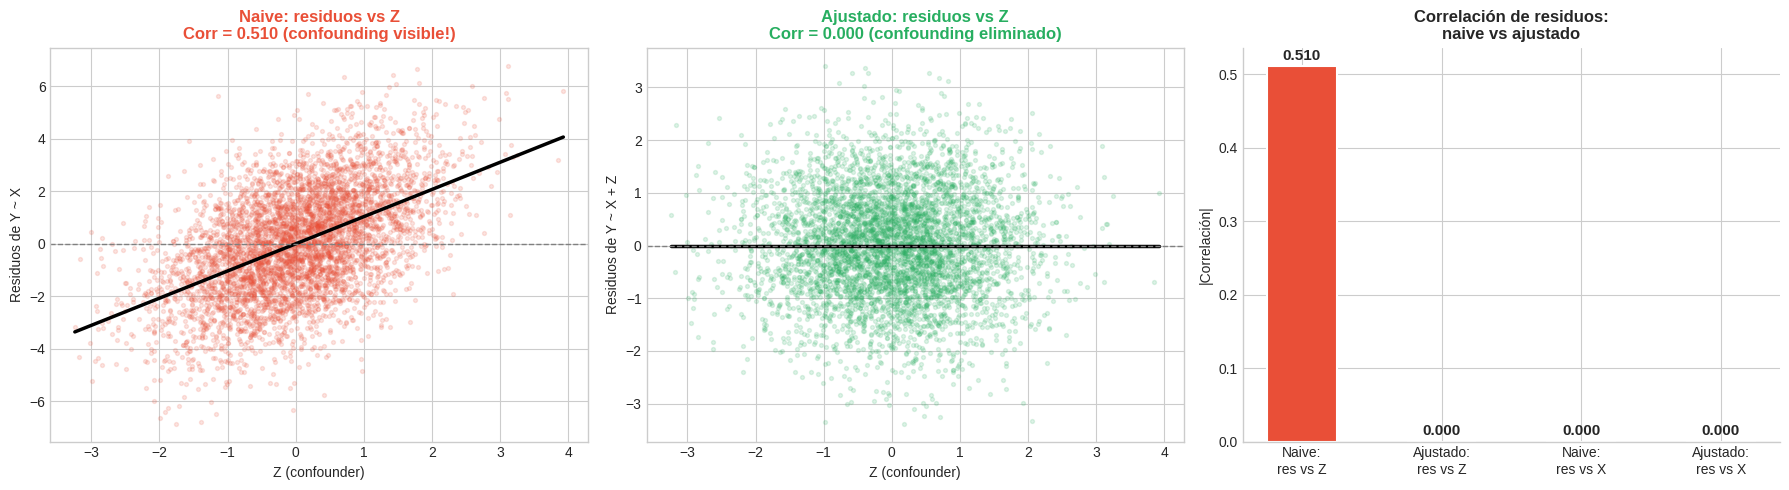


Resumen:
  Naive  — residuos correlacionados con Z: Corr = 0.510 (confounding!)
  Ajust. — residuos independientes de Z:   Corr = 0.000 (limpio)

→ Los residuos de la regresión naive "contienen" información de Z.
  Al ajustar por Z, esa información desaparece: evidencia de que Z es el confounder correcto.


In [12]:
# ------------------------------------------------------------------
# Diagnóstico 3: Residuos y confounding — naive vs ajustado
# ------------------------------------------------------------------

# Residuos de la regresión NAIVE (Y ~ X, sin Z)
res_naive = df['Y'] - np.polyval(coefs_naive, df['X'])

# Residuos de la regresión AJUSTADA (Y ~ X + Z)
X_mat_full = np.column_stack([np.ones(n), df['X'], df['Z']])
betas_full = np.linalg.lstsq(X_mat_full, df['Y'], rcond=None)[0]
res_adjusted = df['Y'] - X_mat_full @ betas_full

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Residuos naive vs Z → CORRELACIONADOS (confounding visible)
axes[0].scatter(df['Z'], res_naive, alpha=0.15, s=8, color='#E94F37')
m_rn, b_rn = np.polyfit(df['Z'], res_naive, 1)
z_line = np.linspace(df['Z'].min(), df['Z'].max(), 50)
axes[0].plot(z_line, m_rn * z_line + b_rn, color='black', lw=2.5)
axes[0].axhline(0, color='gray', lw=1, ls='--')
corr_naive_z = np.corrcoef(df['Z'], res_naive)[0, 1]
axes[0].set_xlabel('Z (confounder)')
axes[0].set_ylabel('Residuos de Y ~ X')
axes[0].set_title(f'Naive: residuos vs Z\nCorr = {corr_naive_z:.3f} (confounding visible!)',
                  fontweight='bold', color='#E94F37')

# Panel 2: Residuos ajustados vs Z → INDEPENDIENTES (confounding eliminado)
axes[1].scatter(df['Z'], res_adjusted, alpha=0.15, s=8, color='#27AE60')
m_ra, b_ra = np.polyfit(df['Z'], res_adjusted, 1)
axes[1].plot(z_line, m_ra * z_line + b_ra, color='black', lw=2.5)
axes[1].axhline(0, color='gray', lw=1, ls='--')
corr_adj_z = np.corrcoef(df['Z'], res_adjusted)[0, 1]
axes[1].set_xlabel('Z (confounder)')
axes[1].set_ylabel('Residuos de Y ~ X + Z')
axes[1].set_title(f'Ajustado: residuos vs Z\nCorr = {corr_adj_z:.3f} (confounding eliminado)',
                  fontweight='bold', color='#27AE60')

# Panel 3: Barras comparativas
labels = ['Naive:\nres vs Z', 'Ajustado:\nres vs Z', 'Naive:\nres vs X', 'Ajustado:\nres vs X']
corr_naive_x = np.corrcoef(df['X'], res_naive)[0, 1]
corr_adj_x = np.corrcoef(df['X'], res_adjusted)[0, 1]
vals = [abs(corr_naive_z), abs(corr_adj_z), abs(corr_naive_x), abs(corr_adj_x)]
colors_bar = ['#E94F37', '#27AE60', '#E94F37', '#27AE60']
bars = axes[2].bar(labels, vals, color=colors_bar, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[2].set_ylabel('|Correlación|')
axes[2].set_title('Correlación de residuos:\nnaive vs ajustado', fontweight='bold')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'\nResumen:')
print(f'  Naive  — residuos correlacionados con Z: Corr = {corr_naive_z:.3f} (confounding!)')
print(f'  Ajust. — residuos independientes de Z:   Corr = {corr_adj_z:.3f} (limpio)')
print(f'\n→ Los residuos de la regresión naive "contienen" información de Z.')
print(f'  Al ajustar por Z, esa información desaparece: evidencia de que Z es el confounder correcto.')

### Resumen: ¿qué podemos concluir de los diagnósticos?

| Diagnóstico | Qué verifica | Resultado | Interpretación |
|---|---|---|---|
| Independencia condicional | ¿La correlación $X$-$Y$ se reduce al condicionar en $Z$? | Si | Consistente con $Z$ como confounder |
| Asimetría de residuos | ¿Los residuos son planos en la dirección causal? | Si | Consistente con $X \to Y$ |
| Residuos y confounding | ¿Los residuos naive correlacionan con $Z$? ¿Los ajustados no? | Si | Consistente con el DAG propuesto |

Todos los diagnósticos son **consistentes** con nuestro modelo causal.
Esto es **evidencia a favor**, pero **no prueba**:

- Podría haber otro confounder $W$ que no observamos
- Otro DAG podría producir las mismas implicaciones
- La dirección causal no se puede determinar solo con datos observacionales

**La causalidad viene del modelo (DAG), no de los datos.**
Los datos solo pueden refutar o ser consistentes con el modelo.

### Demostración: sesgo por collider

Hemos visto que ajustar por un **confounder** (fork) elimina sesgo, y que
**no** ajustar por un **mediador** (chain) preserva el efecto total.
Pero, ¿qué pasa si ajustamos por un **collider**?

Recordemos: en un collider $X \to C \leftarrow Y$, las variables $X$ e $Y$
son **independientes**. Pero si condicionamos en $C$, **creamos** una correlación
espuria ([ver collider en las notas](../01_estructuras_causales.md#3-collider-colisionador--selection-bias)).

Vamos a simularlo. Generamos $X$ e $Y$ completamente independientes,
con un efecto común $C = X + Y + \text{ruido}$:

```
X ───→ C ←─── Y
(independientes entre sí)
```

Si no ajustamos por $C$: $\text{Corr}(X, Y) \approx 0$ (correcto).
Si ajustamos por $C$: aparece una **correlación negativa espuria** entre $X$ e $Y$.

**¿Por qué negativa?** Si sabemos que $C$ es alto y $X$ es alto, entonces $Y$
probablemente no necesita ser alto para explicar $C$. El collider hace que
"explicar" una causa reduce la probabilidad de la otra — esto es **explaining away**.

=== Collider: X → C ← Y ===
  X e Y son INDEPENDIENTES por construcción.

  Sin ajustar por C:
    Corr(X, Y) = 0.017  (≈ 0, correcto)

  Ajustando por C (regresión Y ~ X + C):
    Coeficiente de X = -0.809  (debería ser 0!)
    → Ajustar por el collider CREA un efecto espurio negativo.

  Estratificando (solo C medio):
    Corr(X, Y | C medio) = -0.719  (correlación espuria)


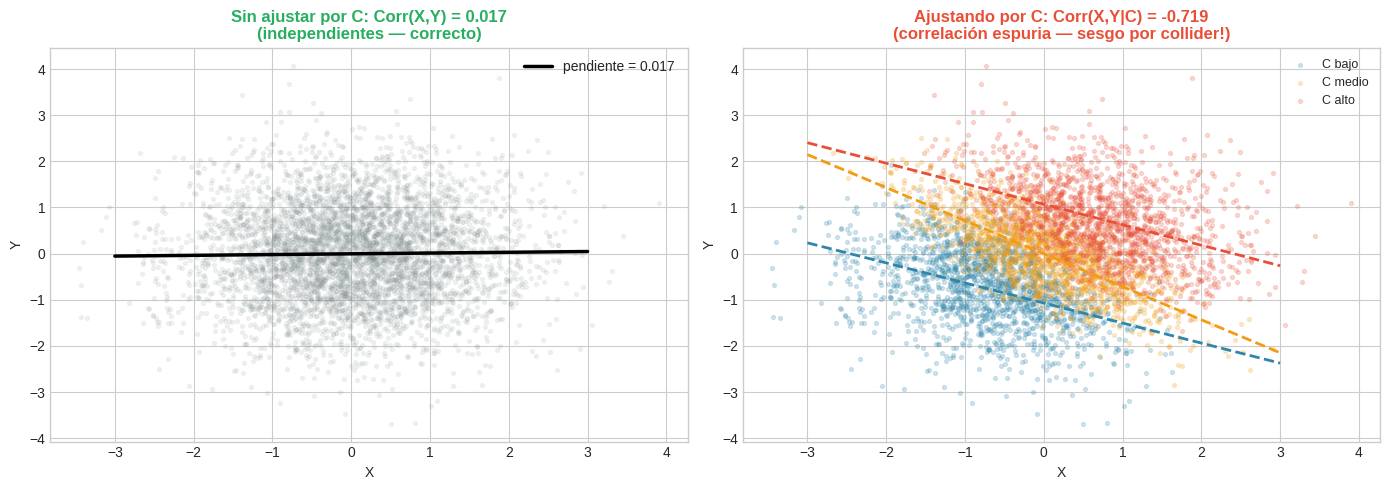


⚠️  NUNCA ajustes por un collider.
   Hacerlo CREA correlación donde no la había.
   Es lo opuesto a un confounder (fork), donde ajustar ELIMINA correlación espuria.


In [13]:
# ------------------------------------------------------------------
# Demostración: sesgo por collider — ajustar por C crea correlación espuria
# ------------------------------------------------------------------

np.random.seed(77)
n_col = 5000

# X e Y son INDEPENDIENTES (no hay flecha entre ellos)
X_col = np.random.normal(0, 1, n_col)
Y_col = np.random.normal(0, 1, n_col)

# C es un collider: efecto común de X e Y
C_col = X_col + Y_col + np.random.normal(0, 0.5, n_col)

df_col = pd.DataFrame({"X": X_col, "Y": Y_col, "C": C_col})

# --- Sin ajustar: X e Y son independientes ---
corr_marginal = df_col["X"].corr(df_col["Y"])

# --- Ajustando por C (regresión Y ~ X + C): aparece correlación espuria ---
X_mat_col = np.column_stack([np.ones(n_col), df_col["X"], df_col["C"]])
betas_col = np.linalg.lstsq(X_mat_col, df_col["Y"], rcond=None)[0]
efecto_espurio = betas_col[1]

# --- Estratificando por C: lo mismo, visualmente ---
c_low = df_col["C"].quantile(0.33)
c_high = df_col["C"].quantile(0.67)
mask_c_mid = (df_col["C"] >= c_low) & (df_col["C"] < c_high)
corr_condicionada = df_col.loc[mask_c_mid, "X"].corr(df_col.loc[mask_c_mid, "Y"])

print("=== Collider: X → C ← Y ===")
print(f"  X e Y son INDEPENDIENTES por construcción.\n")
print(f"  Sin ajustar por C:")
print(f"    Corr(X, Y) = {corr_marginal:.3f}  (≈ 0, correcto)\n")
print(f"  Ajustando por C (regresión Y ~ X + C):")
print(f"    Coeficiente de X = {efecto_espurio:.3f}  (debería ser 0!)")
print(f"    → Ajustar por el collider CREA un efecto espurio negativo.\n")
print(f"  Estratificando (solo C medio):")
print(f"    Corr(X, Y | C medio) = {corr_condicionada:.3f}  (correlación espuria)")

# --- Visualización ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Sin condicionar → independientes
ax1.scatter(df_col["X"], df_col["Y"], alpha=0.1, s=8, color="#7F8C8D")
m1, b1 = np.polyfit(df_col["X"], df_col["Y"], 1)
x_line = np.linspace(-3, 3, 100)
ax1.plot(x_line, m1 * x_line + b1, color="black", lw=2.5,
         label=f"pendiente = {m1:.3f}")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_title(f"Sin ajustar por C: Corr(X,Y) = {corr_marginal:.3f}\n(independientes — correcto)",
              fontweight="bold", color="#27AE60")
ax1.legend()

# Panel 2: Condicionando en C → correlación espuria
for mask, label, color in [
    (df_col["C"] < c_low, "C bajo", "#2E86AB"),
    (mask_c_mid, "C medio", "#F39C12"),
    (df_col["C"] >= c_high, "C alto", "#E94F37"),
]:
    sub = df_col[mask]
    ax2.scatter(sub["X"], sub["Y"], alpha=0.2, s=8, color=color, label=label)
    m2, b2 = np.polyfit(sub["X"], sub["Y"], 1)
    ax2.plot(x_line, m2 * x_line + b2, color=color, lw=2, ls="--")

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_title(f"Ajustando por C: Corr(X,Y|C) = {corr_condicionada:.3f}\n(correlación espuria — sesgo por collider!)",
              fontweight="bold", color="#E94F37")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n⚠️  NUNCA ajustes por un collider.")
print(f"   Hacerlo CREA correlación donde no la había.")
print(f"   Es lo opuesto a un confounder (fork), donde ajustar ELIMINA correlación espuria.")

## 8. Mini-reto: DAG con mediador (chain)

### La historia: un fármaco y un biomarcador

Una farmacéutica desarrolla un nuevo fármaco ($X$) para tratar una enfermedad.
El fármaco actúa de dos maneras sobre la recuperación del paciente ($Y$):

1. **Efecto directo**: el fármaco ataca directamente la enfermedad ($X \to Y$, $\beta = 1.5$)
2. **Efecto indirecto**: el fármaco mejora un biomarcador sanguíneo ($M$),
   y ese biomarcador a su vez ayuda a la recuperación ($X \to M \to Y$)

El DAG es una **cadena** (chain) con efecto directo:

$$X \to M \to Y \quad \text{y} \quad X \to Y$$

```
X (fármaco) ───→ M (biomarcador) ───→ Y (recuperación)
│                                     ↑
└─────────────────────────────────────┘
               (efecto directo)
```

Los parámetros son:
- Efecto directo $X \to Y$: $\beta_{\text{directo}} = 1.5$
- Efecto $X \to M$: $\beta_{X \to M} = 0.8$
- Efecto $M \to Y$: $\beta_{M \to Y} = 1.0$
- Efecto indirecto: $0.8 \times 1.0 = 0.8$
- **Efecto total**: $\beta_{\text{total}} = 1.5 + 0.8 = 2.3$

### La pregunta regulatoria

La agencia reguladora quiere saber: *"¿cuánto mejora la recuperación
si administramos el fármaco?"* Esto es el **efecto total** de $do(X)$.

Un bioestadístico novato decide "controlar por el biomarcador $M$"
(regresión $Y \sim X + M$) pensando que es buena práctica.
Pero $M$ **no es un confounder** — es un **mediador**.

### La trampa

Al ajustar por $M$, el bioestadístico **bloquea el camino indirecto**
$X \to M \to Y$. Recordemos que en una cadena, condicionar en el nodo
central bloquea el flujo de información
([ver chain en las notas](../01_estructuras_causales.md#2-chain-cadena--mediación)).

El resultado: obtiene solo el efecto **directo** ($\hat{\beta}_1 \approx 1.5$)
en lugar del efecto **total** ($2.3$). Subestima el beneficio del fármaco en un 35%.

**Diferencia clave con el ejercicio anterior:**

| Escenario | Variable intermedia | ¿Ajustar? | ¿Por qué? |
|---|---|---|---|
| Fork (agricultor) | $Z$ es confounder | **Sí** | Elimina sesgo espurio |
| Chain (fármaco) | $M$ es mediador | **No** | Bloquea efecto real |

### Preguntas para explorar

1. ¿La estimación naive (regresión $Y \sim X$) funciona aquí? ¿Por qué?
   *Pista: ¿hay algún confounder (fork) en este DAG? ¿O $X$ es exógena?*

2. ¿Qué obtienes si ajustas por $M$ (regresión $Y \sim X + M$)?
   ¿El efecto total o el directo? ¿Por qué?

3. (Bonus) Usa DoWhy para estimar el efecto total.

### Moraleja

**Solo debes ajustar por confounders (forks), nunca por mediadores (chains).**
Ajustar por un mediador bloquea parte del efecto causal que quieres medir.
Saber **qué tipo de variable** tienes requiere el DAG — otra razón por la que
**la causalidad viene del modelo, no de los datos.**

In [14]:
# ------------------------------------------------------------------
# Mini-reto — DAG con mediador (chain)
# ------------------------------------------------------------------
np.random.seed(123)
n = 5000

# Parámetros del DAG
efecto_directo = 1.5   # X -> Y
efecto_x_m = 0.8       # X -> M
efecto_m_y = 1.0       # M -> Y
EFECTO_TOTAL = efecto_directo + efecto_x_m * efecto_m_y  # = 2.3

# Pista: genera los datos según las ecuaciones estructurales
# X es exógena (no tiene padres en el DAG):
# X = np.random.normal(0, 1, n)
#
# M depende de X (camino X → M):
# M = efecto_x_m * X + np.random.normal(0, ?, n)
#
# Y depende de X y M (caminos X → Y directo + M → Y):
# Y = efecto_directo * X + efecto_m_y * M + np.random.normal(0, ?, n)

# TODO: Genera los datos según las ecuaciones estructurales


# TODO 1: Estimación naive (regresión Y ~ X)
# Pista: como X es exógena (no hay confounder), la naive debería funcionar.
# coefs = np.polyfit(X, Y, 1); coefs[0] debería dar ≈ EFECTO_TOTAL


# TODO 2: ¿Qué pasa si ajustas por M? (regresión Y ~ X + M)
# Pista: construye X_mat = np.column_stack([np.ones(n), X, M])
#        betas = np.linalg.lstsq(X_mat, Y, rcond=None)[0]
#        betas[1] dará ≈ efecto_directo (1.5), NO el total (2.3)


# TODO 3 (bonus): Usa DoWhy con un networkx DiGraph
# Pista: grafo = nx.DiGraph([("X", "M"), ("M", "Y"), ("X", "Y")])
#        DoWhy debería identificar que NO hay backdoor paths
#        → no necesita ajustar por nada → efecto total correcto

print(f"Efecto total esperado:   {EFECTO_TOTAL}")
print(f"Efecto directo esperado: {efecto_directo}")
print(f"\nMoraleja: ajustar por un mediador (chain) bloquea parte del efecto causal.")
print(f"Solo debes ajustar por confounders (forks), no por mediadores.")

Efecto total esperado:   2.3
Efecto directo esperado: 1.5

Moraleja: ajustar por un mediador (chain) bloquea parte del efecto causal.
Solo debes ajustar por confounders (forks), no por mediadores.
